# Validate Data: Net & Hot-Only Mortality Impact 

Compute and map net and hot-only temperature-mortality
impacts (age-weighted, 6-month cumulative). Export summary
statistics to CSV.

**Data:**
- **Projection effects** — `260828_effects.zarr`
- **Impact region polygons** — `POREALLAS_REGIONS_POLYGONS_URI`
- **Socioeconomic data** — `POREALLAS_SOCIOECONOMICS_URI` (2026)
- **Output (summary stats)** — `260828_{hotonly}_{scope}_{rate_l}_{stat_scope}stats.csv`

In [34]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [ ]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]

EFFECTS_URI = os.path.join(DATA_DIR, "260828_effects.zarr") # Local version 
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [ ]:
# Projection Effects
effect = xr.open_datatree(
    EFFECTS_URI,
    engine="zarr",
    chunks={})

baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

# Plot Data

In [30]:
### Net Impact ###
impact_net = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = "net", rate = False, age_weight = True)
_polygons_impact_net = analysis_utils.xarray_to_gpd(impact_net.mean(dim = ['number', 'sample']), _polygons)
_polygons_impact_net['age_weighted_impact'].describe()

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


count    170485.000000
mean         -1.324632
std          12.864724
min        -372.590660
25%          -1.489235
50%          -0.092567
75%           0.022937
max         778.060102
Name: age_weighted_impact, dtype: float64

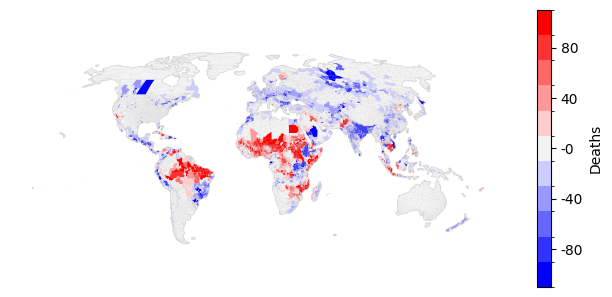

In [ ]:
# Plot 6-month Cumulative Impact
fig = analysis_utils.plot_aggregate(
    _polygons_impact_net,
    col='age_weighted_impact',
    agg = 'sum',
    cm = 'bwr',
    n_colors = 11,
    sup_title="",
    cbar_label= impact_net.units,
)

In [27]:
### Hot-Only Impact ###
impact_hotonly = analysis_utils.compute_impact(effect, socioeconomics, ensemble = True, baseline_period=baseline_period, hotonly = "hotonly", rate = False, age_weight = True)
_polygons_impact_hotonly = analysis_utils.xarray_to_gpd(impact_hotonly.mean(dim = ['number', 'sample']), _polygons)
_polygons_impact_hotonly['age_weighted_impact'].describe()

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(


count    170485.000000
mean          1.977376
std           9.837937
min        -349.658624
25%           0.000000
50%           0.029441
75%           0.688337
max         793.093381
Name: age_weighted_impact, dtype: float64

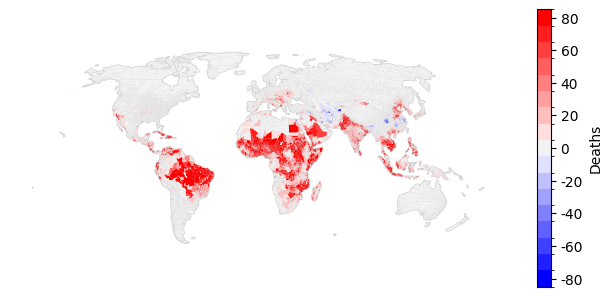

In [28]:
# Plot 6-month Cumulative Impact
fig = analysis_utils.plot_aggregate(
    _polygons_impact_hotonly,
    col='age_weighted_impact',
    agg = 'sum',
    cm = 'bwr',
    n_colors = 11,
    sup_title="",
    cbar_label= impact_hotonly.units,
)

In [36]:
analysis_utils.make_csv(
    effect,
    socioeconomics,
    _polygons,
    baseline_period,
    ensemble=True,
    dims = ["number", "sample"],
    hotonly="hotonly",
    rate=False,
    age_weight=True,
    filename_template="260828_{hotonly}_{scope}_{rate_l}_{stat_scope}stats.csv",
    output_scope = ["global_6mo"]
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 13
  result = blockwise(
